# Modulator masks from mode amplitudes, at any resolution

Given a vector of mode amplitudes, what field should the modulator display? The fitted
change-of-basis matrix answers that on the pixel grid it was fitted on — 35x35 at the
input, 41x41 at the output. Those are the grids the *transmission matrix* was measured
on; they are not necessarily the grids you want to address the modulator with.

`PyTorchAberrations.mode_masks` builds the same field on a grid of any size, spanning the
same physical area. The fitted model is a description of the **optics**, so it can be
applied to a mode basis sampled as finely as you like.

> ### Run [`Demo_correction_aberration.ipynb`](Demo_correction_aberration.ipynb) first
>
> It writes `data/fitted_correction.pt` — the fitted weights and the corrected
> change-of-basis matrices. That file is **not** in the repository (it is in
> `.gitignore`), because it is a result, not data. Nothing here optimises anything: this
> notebook only loads.

**What is checked, in order.**

1. A **reference** field, built from the saved change-of-basis matrix — the actual output
   of the optimisation, *not* recomputed from the model.
2. The same field from the **model at the native resolution**. It must reproduce the
   reference. This is the sanity check that the geometry is right.
3. The same field from the **model at 3x the resolution**, and what happens when it is
   brought back to the native grid.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
%matplotlib inline

try:
    import PyTorchAberrations
except ImportError:          # running from a checkout without `pip install -e .`
    sys.path.insert(0, os.path.abspath('..'))

from PyTorchAberrations.aberration_models import AberrationModes
from PyTorchAberrations.mode_masks import ModeMasks
from PyTorchAberrations.plotting_functions import colorize

DATA = './data'
CKPT = os.path.join(DATA, 'fitted_correction.pt')

if not os.path.exists(CKPT):
    raise FileNotFoundError(
        f'{CKPT} not found.\n\n'
        'Run Demo_correction_aberration.ipynb first — it fits the aberration model and\n'
        'saves it there. The file is not tracked by git.')

ckpt = torch.load(CKPT, weights_only=False)
cfg = ckpt['config']
r = ckpt['ratios']
print(f"loaded a fit reaching conversion {r['conversion']:.2f} %, "
      f"diagonal {r['diagonal']:.2f} %")
print('config:', {k: v for k, v in cfg.items() if not k.startswith('list_')})

loaded a fit reaching conversion 92.55 %, diagonal 91.23 %
config: {'inpoints': 35, 'onpoints': 41, 'padding_coeff': 0.05, 'deformation': 'scaling', 'pola_inout': (2, 2), 'conj_out': True}


## 1. Rebuild the model and load the weights

No optimiser, no cost function, no loop. `AberrationModes` is constructed from the saved
configuration and the fitted parameters are loaded into it.

In [2]:
model = AberrationModes(inpoints=cfg['inpoints'], onpoints=cfg['onpoints'],
                        padding_coeff=cfg['padding_coeff'],
                        list_zernike_ft=cfg['list_zernike_ft'],
                        list_zernike_direct=cfg['list_zernike_direct'],
                        deformation=cfg['deformation'])
model.load_state_dict(ckpt['state_dict'])
model.eval()

N_in, N_out = cfg['inpoints'], cfg['onpoints']
print(f'{sum(p.numel() for p in model.parameters())} fitted scalars loaded, '
      f'input grid {N_in}x{N_in}, output grid {N_out}x{N_out}')

# the theoretical modes and the TM: the TM is used only to measure the magnification,
# exactly as get_inout_modes does inside the correction notebook
TM = np.load(os.path.join(DATA, 'TM_pix.npy'))
TM = TM / np.max(np.abs(TM))
TM[np.abs(TM) < 1e-3] = 0
profiles = np.load(os.path.join(DATA, 'modes_hd.npz'))['profiles']

mm = ModeMasks.from_tm(model, profiles, TM,
                       pola_inout=cfg['pola_inout'],
                       padding_coeff=cfg['padding_coeff'],
                       conj_out=cfg['conj_out'])
nmodes = mm.nmodes
print(mm.info('in'))

48 fitted scalars loaded, input grid 35x35, output grid 41x41
{'side': 'in', 'native_resolution': 35, 'resolution': 35, 'oversampling': 1.0, 'hd_zoom': 0.2694888057432222, 'padded': 37, 'padded_native': 37, 'hd_pixels_per_output_pixel': 3.7107292721940843}


## 2. The reference, from the fitted change-of-basis matrix

**This is the point to be clear about.** The reference field below is built from
`modes_in_corr`, the matrix the optimisation produced and that section 6 of the
correction notebook hands you. It is *not* recomputed from the model — it is the ground
truth the model has to match.

The synthesis convention is the one the cost function was written with,
`TM_modes = modes_out @ TM_pix @ modes_in^H`, so a mode-amplitude vector `a` corresponds
to the pixel field

$$u = M^{H} a = \sum_k a_k \, \overline{M_k}$$

In [3]:
modes_in_corr = ckpt['modes_in_corr']          # (nmodes, N_in**2) -- straight from the fit
print('reference basis from the checkpoint:', modes_in_corr.shape, modes_in_corr.dtype)

rng = np.random.default_rng(0)
a = rng.normal(size=nmodes) + 1j * rng.normal(size=nmodes)
a /= np.linalg.norm(a)

u_ref = (modes_in_corr.conj().T @ a).reshape(N_in, N_in)      # <-- the reference
print(f'random combination of all {nmodes} modes, reference field {u_ref.shape}')

reference basis from the checkpoint: (55, 1225) complex128
random combination of all 55 modes, reference field (35, 35)


## 3. Sanity check: the model on the native grid

`mask_from_modes` with no `resolution` argument rebuilds the basis from the
high-definition profiles, applies the fitted aberration, and combines. It must land on
the reference.

It is not obvious that it should. The correction notebook builds its basis with
`scaling_functions.resize_modes`, whose sampling grid has an effective pitch of
`(n_hd - 1) / (n_zoom - 1)` — 3.7 % away from the nominal `1 / zoom` — and an origin
displaced by a floor-divided crop offset. Sampling the profiles on a "clean" centred grid
instead would give a field **56 %** away from this one. `mode_masks` reproduces that grid
deliberately.

model on the native grid vs the fitted basis: relative error 3.12e-07


Text(0.5, 0.98, 'Amplitude and phase as hue; the model reproduces the fit')

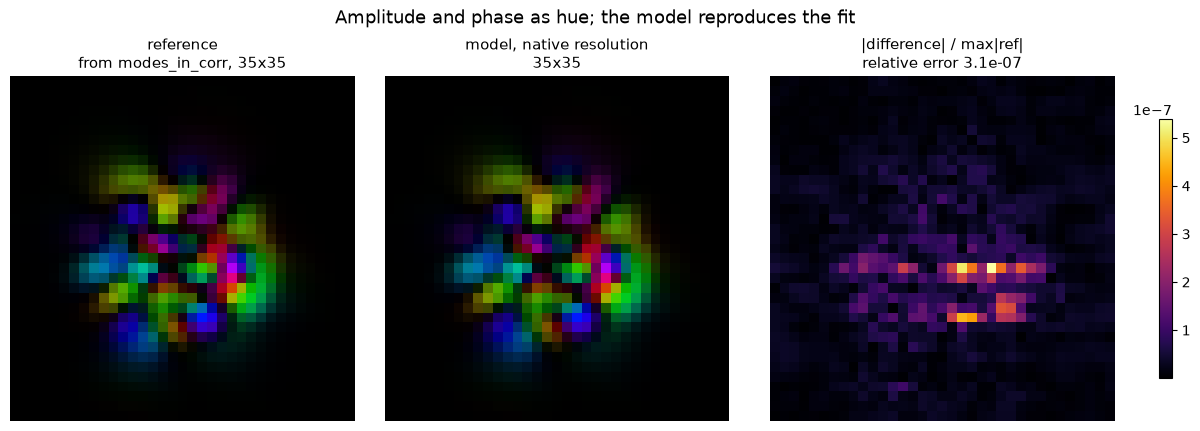

In [4]:
u_native = mm.mask_from_modes(a, side='in')       # resolution defaults to native


def relerr(x, ref):
    return np.linalg.norm(x - ref) / np.linalg.norm(ref)


err = relerr(u_native, u_ref)
print(f'model on the native grid vs the fitted basis: relative error {err:.2e}')
assert err < 1e-5, 'the native reconstruction must match the fitted basis'

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), layout='constrained')
axes[0].imshow(colorize(u_ref))
axes[0].set_title(f'reference\nfrom modes_in_corr, {N_in}x{N_in}', fontsize=11)
axes[1].imshow(colorize(u_native))
axes[1].set_title(f'model, native resolution\n{N_in}x{N_in}', fontsize=11)
im = axes[2].imshow(np.abs(u_native - u_ref) / np.abs(u_ref).max(), cmap='inferno')
axes[2].set_title(f'|difference| / max|ref|\nrelative error {err:.1e}', fontsize=11)
fig.colorbar(im, ax=axes[2], shrink=0.75)
for ax in axes:
    ax.axis('off')
fig.suptitle('Amplitude and phase as hue; the model reproduces the fit', fontsize=13)

## 4. The same field, three times more finely sampled

Now the point of the module. `resolution=3 * N_in` asks for the same physical field of
view on a 105x105 grid.

Nothing about the fit is redone: the Zernike coefficients are reinterpreted on the finer
grid — the direct-plane coordinates are unchanged in physical terms, the Fourier-plane
ones cover a Nyquist band three times wider, so the pupil occupies a third of the domain.

105x105 mask over the same physical area
{'side': 'in', 'native_resolution': 35, 'resolution': 105, 'oversampling': 3.0, 'hd_zoom': 0.2694888057432222, 'padded': 111, 'padded_native': 37, 'hd_pixels_per_output_pixel': 1.236909757398028}


Text(0.5, 0.98, 'Same field of view, same physical field, three times the sampling')

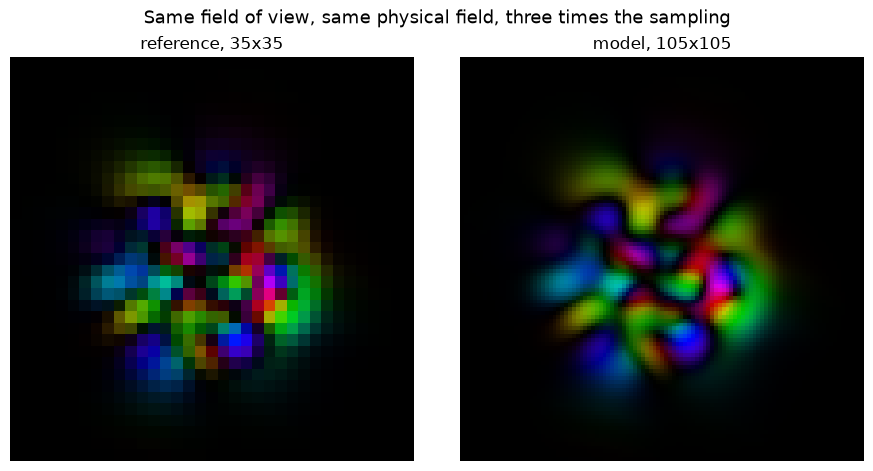

In [5]:
S = 3
u_hi = mm.mask_from_modes(a, side='in', resolution=S * N_in)
print(f'{u_hi.shape[0]}x{u_hi.shape[1]} mask over the same physical area')
print(mm.info('in', S * N_in))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), layout='constrained')
axes[0].imshow(colorize(u_ref))
axes[0].set_title(f'reference, {N_in}x{N_in}', fontsize=12)
axes[1].imshow(colorize(u_hi))
axes[1].set_title(f'model, {S * N_in}x{S * N_in}', fontsize=12)
for ax in axes:
    ax.axis('off')
fig.suptitle('Same field of view, same physical field, three times the sampling',
             fontsize=13)

## 5. Does the fine grid agree with the coarse one?

On a grid `s` times finer with odd `s`, the native sample positions land at
`field[(s-1)//2::s, (s-1)//2::s]`. Two cautions before comparing:

* the module normalises each basis over the grid it was built on, so the same physical
  field comes back `s` times smaller in amplitude on an `s` times finer grid — compare
  *shapes*, each field divided by its own norm;
* the answer is then about **3 %**, not the 1e-7 of section 3.

That 3 % is **the native model's error, not the fine grid's**, and the table below is the
evidence: `s = 3`, `5` and `7` agree with each other better than any of them agrees with
`s = 1`. The refined grids converge to a common answer; the coarse one is the outlier.

The culprit is the deformation layer: `grid_sample` has to guess the field between
samples, and a 37x37 padded array gives it much less to work with than a 111x111 one. The
Zernike terms themselves transfer essentially exactly — the direct-plane ones to 1e-15,
the Fourier-plane ones to 3e-3. (Before 0.3 this figure was 5 %; the deformation
interpolated bilinearly.)

        grid  vs the native reference
       35x35                 3.12e-07   <- section 3
     105x105                 2.80e-02
     175x175                 2.65e-02
     245x245                 2.58e-02

        pair  agreement with each other
  s=3 vs s=5                   1.52e-02
  s=5 vs s=7                   9.62e-03


Text(0.5, 1.0, 'The refined grids agree with each other, not with the coarse one')

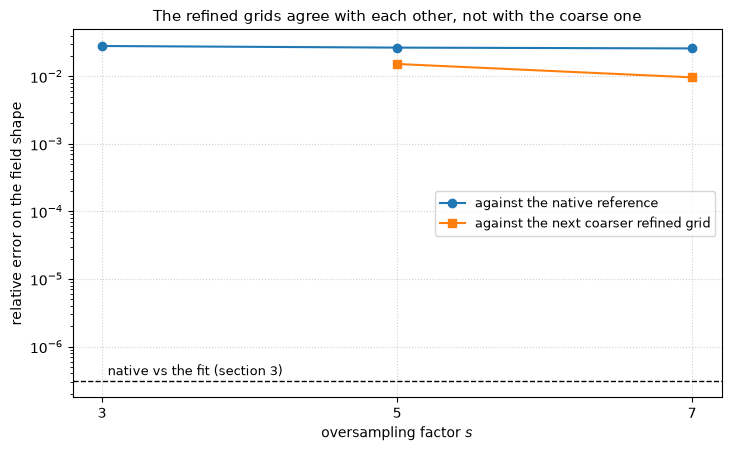

In [6]:
# the native sample positions of a field computed on an s-times-finer grid
def on_native_grid(field, s):
    return field[(s - 1) // 2::s, (s - 1) // 2::s]


# each basis is normalised over its own grid, so compare shape, not amplitude
def shape_err(x, ref):
    return np.linalg.norm(x.ravel() / np.linalg.norm(x)
                          - ref.ravel() / np.linalg.norm(ref))


rows = []
for s in [3, 5, 7]:
    u_s = mm.mask_from_modes(a, side='in', resolution=s * N_in)
    rows.append((s, on_native_grid(u_s, s)))

print(f'{"grid":>12} {"vs the native reference":>24}')
print(f'{f"{N_in}x{N_in}":>12} {shape_err(u_native, u_ref):>24.2e}   <- section 3')
for s, u_s in rows:
    print(f'{f"{s*N_in}x{s*N_in}":>12} {shape_err(u_s, u_ref):>24.2e}')

print(f'\n{"pair":>12} {"agreement with each other":>26}')
for (s1, u1), (s2, u2) in zip(rows, rows[1:]):
    print(f'{f"s={s1} vs s={s2}":>12} {shape_err(u2, u1):>26.2e}')

fig, ax = plt.subplots(figsize=(7.2, 4.4), layout='constrained')
ax.semilogy([s for s, _ in rows], [shape_err(u, u_ref) for _, u in rows], 'o-',
            label='against the native reference')
ax.semilogy([s2 for (_, _), (s2, _) in zip(rows, rows[1:])],
            [shape_err(u2, u1) for (_, u1), (_, u2) in zip(rows, rows[1:])], 's-',
            label='against the next coarser refined grid')
ax.axhline(shape_err(u_native, u_ref), color='k', ls='--', lw=1)
ax.annotate('native vs the fit (section 3)', xy=(3, shape_err(u_native, u_ref)),
            xytext=(4, 4), textcoords='offset points', fontsize=9)
ax.set_xlabel('oversampling factor $s$')
ax.set_ylabel('relative error on the field shape')
ax.set_xticks([s for s, _ in rows])
ax.grid(ls=':', alpha=0.6)
ax.legend(fontsize=9, loc='center right')
ax.set_title('The refined grids agree with each other, not with the coarse one',
             fontsize=11)

So for driving a modulator the high-resolution mask is the one to use: it is not an
interpolation of the native mask, it is the same physical field computed without the
coarse grid's interpolation error.

## 6. The other side, and the round trip

`side` selects which of the two `Aberration` sub-models is applied. Input and output see
different aberrations and different native grids, so this is not cosmetic.
`modes_from_mask` inverts the synthesis, at whatever resolution the field is given on.
It offers two ways to do it, and the difference is instructive: `method='conj'` uses
`a = M u`, which is the exact inverse only for an orthonormal basis, while
`method='pinv'` goes through the dual basis and is exact regardless.

output side: native 41x41, asked for 82x82

 side  resolution         conj         pinv
   in       35x35     1.62e-02     3.01e-15
   in     105x105     1.02e-02     2.04e-15
  out       41x41     8.33e-03     1.89e-15


  out     123x123     6.02e-03     2.46e-15


Text(0.5, 0.98, 'The two sides carry different aberrations')

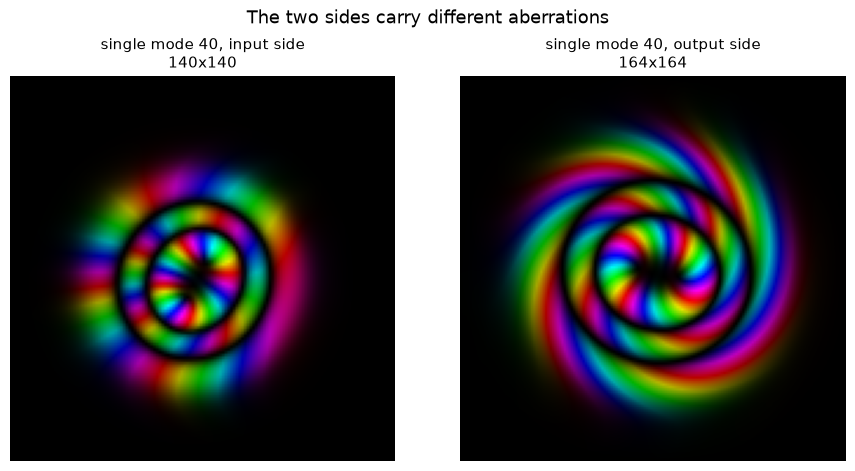

In [7]:
u_out = mm.mask_from_modes(a, side='out', resolution=2 * N_out)
print(f'output side: native {N_out}x{N_out}, asked for {u_out.shape[0]}x{u_out.shape[1]}')

print(f'\n{"side":>5} {"resolution":>11} {"conj":>12} {"pinv":>12}')
for side, n_native in [('in', N_in), ('out', N_out)]:
    for s in [1, 3]:
        field = mm.mask_from_modes(a, side=side, resolution=s * n_native)
        errs = [shape_err(mm.modes_from_mask(field, side=side, method=m), a)
                for m in ('conj', 'pinv')]
        print(f'{side:>5} {f"{s*n_native}x{s*n_native}":>11} '
              f'{errs[0]:>12.2e} {errs[1]:>12.2e}')

fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), layout='constrained')
axes[0].imshow(colorize(mm.mask_for_mode(40, side='in', resolution=4 * N_in)))
axes[0].set_title(f'single mode 40, input side\n{4 * N_in}x{4 * N_in}', fontsize=11)
axes[1].imshow(colorize(mm.mask_for_mode(40, side='out', resolution=4 * N_out)))
axes[1].set_title(f'single mode 40, output side\n{4 * N_out}x{4 * N_out}', fontsize=11)
for ax in axes:
    ax.axis('off')
fig.suptitle('The two sides carry different aberrations', fontsize=13)

`pinv` is exact everywhere, to machine precision. `conj` is not, and the reason is worth
knowing: **the corrected basis is not exactly orthonormal**. The fit maximises captured
energy, nothing constrains the Gram matrix, and the aberration it applies does not
preserve orthogonality — so the residual is around 1 % here. Use `pinv` unless the basis
is known to be orthonormal.

## Summary

| | |
|---|---|
| the reference | `modes_in_corr` from the checkpoint — the optimisation's own output |
| model, native grid | reproduces it to ~1e-7 |
| model, 3x finer | same physical field; differs from the *native* one by ~3 %, which is the native grid's interpolation error |
| `side='in'` / `'out'` | different aberration, different native grid |
| `modes_from_mask` | `method='pinv'` inverts exactly; `method='conj'` assumes an orthonormal basis, which the fitted one is not |

The one thing that must be got right, and is easy to miss: the basis has to be sampled on
the grid `resize_modes` actually laid down, not on a nominally clean one. Getting it wrong
is a 56 % error that looks like a plausible field.